In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/accepted_features.csv', low_memory=False)

print(df['loan_status'].value_counts())

loan_status
Fully Paid                                             53884
Current                                                44264
Charged Off                                            13294
Late (31-120 days)                                      1038
In Grace Period                                          411
Late (16-30 days)                                        201
Does not meet the credit policy. Status:Fully Paid       100
Does not meet the credit policy. Status:Charged Off       50
Default                                                    2
Name: count, dtype: int64


In [2]:
dpd_mapping = {
    'Current': 'Current',
    'In Grace Period': '1-15 DPD',
    'Late (16-30 days)': '16-30 DPD',
    'Late (31-120 days)': '31-120 DPD',
    'Default': '120+ DPD',
    'Charged Off': 'Charged Off',
    'Fully Paid': 'Fully Paid',
    'Does not meet the credit policy. Status:Fully Paid': 'Fully Paid',
    'Does not meet the credit policy. Status:Charged Off': 'Charged Off'
}

df['dpd_bucket'] = df['loan_status'].map(dpd_mapping)

print(df['dpd_bucket'].value_counts())

dpd_bucket
Fully Paid     53984
Current        44264
Charged Off    13344
31-120 DPD      1038
1-15 DPD         411
16-30 DPD        201
120+ DPD           2
Name: count, dtype: int64


In [5]:
roll_matrix = df.groupby(['grade', 'dpd_bucket']).size().unstack(fill_value=0)
roll_matrix_pct = roll_matrix.div(roll_matrix.sum(axis=1), axis=0).round(3) * 100
print(roll_matrix_pct)

dpd_bucket  1-15 DPD  120+ DPD  16-30 DPD  31-120 DPD  Charged Off  Current  \
grade                                                                         
A                0.1       0.0        0.0         0.3          3.1     45.6   
B                0.3       0.0        0.1         0.7          7.9     39.8   
C                0.4       0.0        0.3         1.2         13.3     39.6   
D                0.6       0.0        0.3         1.4         18.1     35.5   
E                0.7       0.0        0.4         1.5         26.4     29.0   
F                0.5       0.0        0.2         1.4         35.5     18.7   
G                0.5       0.0        0.2         2.4         37.5     20.6   

dpd_bucket  Fully Paid  
grade                   
A                 50.9  
B                 51.2  
C                 45.3  
D                 44.2  
E                 42.1  
F                 43.6  
G                 38.9  


In [7]:
col_order = ['Current', '1-15 DPD', '16-30 DPD', '31-120 DPD', '120+ DPD', 'Charged Off', 'Fully Paid']
row_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

roll_plot = roll_matrix_pct.reindex(index=row_order, columns=col_order).fillna(0)
roll_plot.head()

dpd_bucket,Current,1-15 DPD,16-30 DPD,31-120 DPD,120+ DPD,Charged Off,Fully Paid
grade,,,,,,,
A,45.6,0.1,0.0,0.3,0.0,3.1,50.9
B,39.8,0.3,0.1,0.7,0.0,7.9,51.2
C,39.6,0.4,0.3,1.2,0.0,13.3,45.3
D,35.5,0.6,0.3,1.4,0.0,18.1,44.2
E,29.0,0.7,0.4,1.5,0.0,26.4,42.1


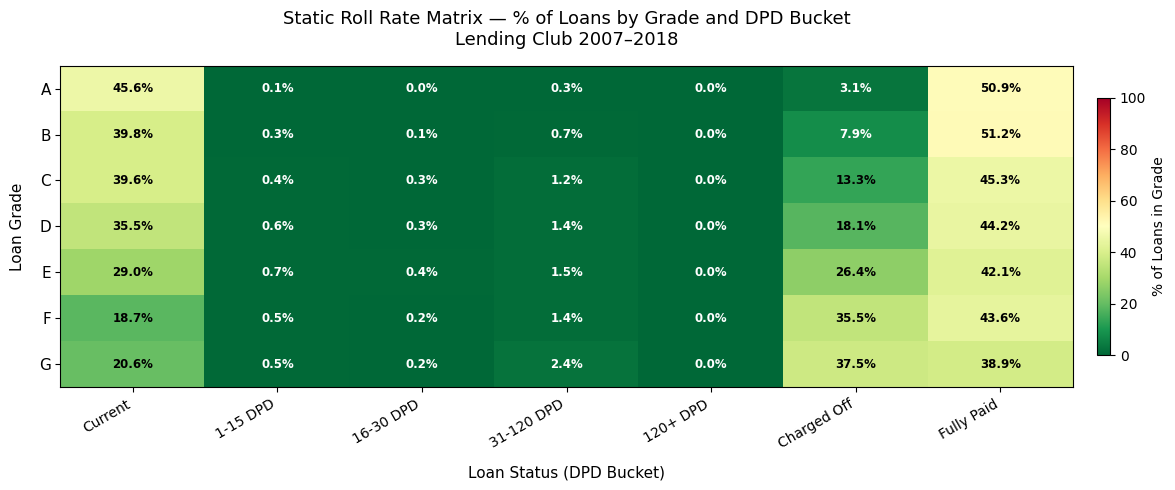

Saved.


In [38]:
fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(roll_plot.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)


ax.set_xticks(range(len(roll_plot.columns)))
ax.set_xticklabels(roll_plot.columns, rotation=30, ha='right', fontsize=10)

ax.set_yticks(range(len(roll_plot.index)))
ax.set_yticklabels(roll_plot.index, fontsize=11)

ax.set_xlabel('Loan Status (DPD Bucket)', fontsize=11, labelpad=10)
ax.set_ylabel('Loan Grade', fontsize=11, labelpad=10)
ax.set_title(
    'Static Roll Rate Matrix — % of Loans by Grade and DPD Bucket\nLending Club 2007–2018',
    fontsize=13, pad=15
)

for i in range(len(roll_plot.index)):      
    for j in range(len(roll_plot.columns)):
        val = roll_plot.values[i, j]

        text_color = 'black' if val > 10 else 'white'

        ax.text(
            j, i,              # position: column index, row index
            f'{val:.1f}%',     # e.g. "13.3%"
            ha='center', va='center',
            fontsize=8.5, fontweight='bold',
            color=text_color
        )


cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('% of Loans in Grade', fontsize=10)

plt.tight_layout()

plt.savefig(
    '../outputs/04_roll_rate_matrix_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()
print("Saved.")

## Interpretation: Static Roll Rate Matrix

### Key observations

**Charge-Off rate increases monotonically with grade risk:**
- Grade A: 3.1% charged off — lowest risk, as expected
- Grade G: 37.5% charged off — over 1 in 3 loans never recovered
- This confirms loan grade is a strong predictor of credit loss

**"Fully Paid" rate does NOT perfectly mirror charge-off:**
- Grade B (51.2%) has a *higher* fully paid rate than Grade A (50.9%)
- Grade F (43.6%) is higher than Grade G (38.9%)
- Reason: lower-grade loans have more loans still "Current" at snapshot date,
  meaning they haven't resolved yet — not that they performed better

**Current loans hide future risk:**
- Grade A: 45.6% still Current vs Grade G: only 20.6%
- Higher-grade loans are newer or longer-term — outcome not yet determined
- A static snapshot understates eventual losses for recent vintages

**Early delinquency buckets (1-15, 16-30 DPD) are small but meaningful:**
- These are loans actively rolling toward charge-off
- Grade G has the highest 31-120 DPD rate at 2.4% — 
  early warning signal for future losses

### Business implication
A credit analyst at a bank would use this matrix to set 
**risk-based pricing**: Grade G loans should carry significantly 
higher interest rates to compensate for the ~37.5% charge-off rate 
versus Grade A's 3.1%.